In [42]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
thresholds = pd.read_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/src/stages/pattern_classification/models/metrics/1768980092.9215467/best_thresholds_per_fold.csv')

In [37]:
thresholds.mean()

Advanced LLM Prompting                          0.38
Agent Architecture                              0.37
Evaluating LLM Results                          0.30
Forecasting with Classical Models               0.37
LLM-based Multimodal Generative Prompting       0.46
LLM-based Planning, XoT, ReAct, or Reasoning    0.48
Model Abstraction                               0.44
Preprocessing Text and Numerical Data           0.35
Retrieval Augmented Generation(RAG)             0.37
Using Tools with LLMs                           0.29
dtype: float64

In [39]:
mean_thresholds = thresholds.mean()
mean_thresholds['none'] = 0

In [40]:
def get_class(row):
    row = row.drop('verified_pattern')
    max_prob = row.max()
    max_prob_index = row.idxmax()
    # return max_prob_index

    threshold = mean_thresholds[max_prob_index]
    if max_prob >= threshold:
        return max_prob_index
    else:
        return 'none'
    
def classification_report(true_labels, predicted_labels):
    from sklearn.metrics import classification_report
    report = classification_report(true_labels, predicted_labels, zero_division=0, output_dict=True)
    return pd.DataFrame(report).transpose()

In [41]:
probab_distributions = pd.read_csv('/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/src/stages/pattern_classification/models/metrics/1768980092.9215467/test_probability_distributions.csv')
probab_distributions['predicted_class'] = probab_distributions.apply(get_class, axis=1)
report_df = classification_report(probab_distributions['verified_pattern'], probab_distributions['predicted_class'])
report_df

,precision,recall,f1-score,support
Advanced LLM Prompting,0.285714,0.142857,0.190476,14.00000
Agent Architecture,0.500000,0.300000,0.375000,20.00000
Evaluating LLM Results,0.571429,0.222222,0.320000,18.00000
Forecasting with Classical Models,0.719298,0.650794,0.683333,63.00000
LLM-based Multimodal Generative Prompting,0.581818,0.615385,0.598131,52.00000
"LLM-based Planning, XoT, ReAct, or Reasoning",0.714286,0.416667,0.526316,12.00000
Model Abstraction,0.421053,0.400000,0.410256,20.00000
Preprocessing Text and Numerical Data,0.479167,0.460000,0.469388,50.00000
Retrieval Augmented Generation(RAG),0.652174,0.535714,0.588235,28.00000
Using Tools with LLMs,0.212121,0.225806,0.218750,31.00000


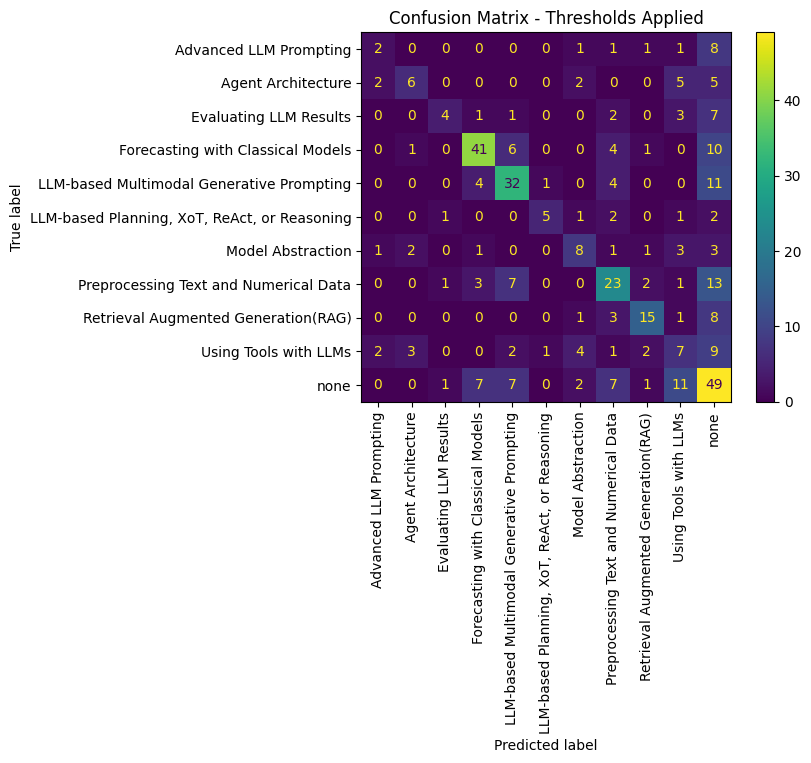

In [46]:
y_true = probab_distributions['verified_pattern']
y_pred = probab_distributions['predicted_class']
class_labels = np.unique(np.concatenate([y_true, y_pred]))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_labels
)

disp.plot()
plt.xticks(rotation=90)
plt.title(f"Confusion Matrix - Thresholds Applied")
plt.show()

In [17]:
probab_distributions

,Advanced LLM Prompting,Agent Architecture,Evaluating LLM Results,Forecasting with Classical Models,LLM-based Multimodal Generative Prompting,"LLM-based Planning, XoT, ReAct, or Reasoning",Model Abstraction,Preprocessing Text and Numerical Data,Retrieval Augmented Generation(RAG),Using Tools with LLMs,none,verified_pattern
0,0.009490,0.012226,0.011429,0.003093,0.009026,0.012422,0.008128,0.022650,0.016535,0.066037,0.865201,none
1,0.010603,0.016766,0.011355,0.019676,0.117505,0.023566,0.010500,0.017425,0.006591,0.375031,0.427222,LLM-based Multimodal Generative Prompting
2,0.027359,0.014243,0.008761,0.010134,0.775177,0.039544,0.010835,0.024791,0.006228,0.083349,0.035817,LLM-based Multimodal Generative Prompting
3,0.029269,0.023943,0.058331,0.215967,0.030190,0.105330,0.024359,0.169278,0.028583,0.284181,0.066808,"LLM-based Planning, XoT, ReAct, or Reasoning"
4,0.036305,0.029541,0.039755,0.097751,0.032604,0.034115,0.026103,0.364187,0.143292,0.152414,0.080171,Preprocessing Text and Numerical Data
...,...,...,...,...,...,...,...,...,...,...,...,...
388,0.022291,0.014594,0.022638,0.755578,0.057620,0.019130,0.014591,0.038381,0.024352,0.012994,0.058034,Forecasting with Classical Models
389,0.026774,0.011950,0.036588,0.107896,0.021190,0.041367,0.008066,0.550508,0.008827,0.030868,0.196169,Evaluating LLM Results
390,0.001444,0.004668,0.016287,0.173021,0.391186,0.001527,0.001010,0.382371,0.005629,0.026299,0.036760,LLM-based Multimodal Generative Prompting
391,0.004527,0.017328,0.013851,0.009431,0.009665,0.015636,0.003379,0.001025,0.002584,0.433584,0.529192,none
